<a href="https://www.pieriandata.com"><img src="data/Logo.jpg"></a>
*Copyright by Pierian Data Inc.*

# Image Thresholding

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

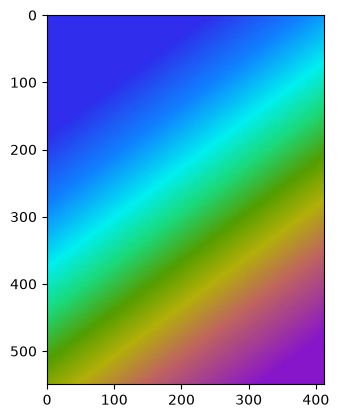

In [2]:
img = cv2.imread('data/rainbow.jpg')
plt.imshow(img)

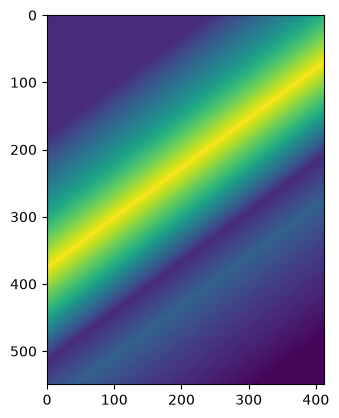

In [3]:
# Add flat '0' to read the image in black & white
img = cv2.imread('data/rainbow.jpg', 0)
plt.imshow(img)

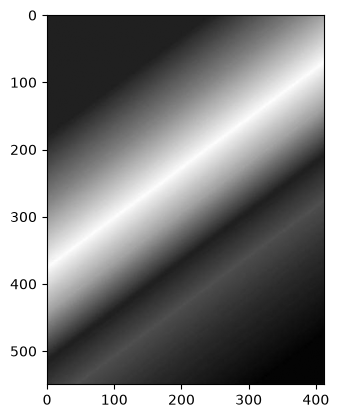

In [4]:
# Show in black & white mode
plt.imshow(img, 'gray')

## Different Threshold Types

![OpenCV_Thresholding](data/opencv_thresholding.jpg)

### Binary

`cv2.threshold()` is used to convert an image into a **binary image** based on a threshold value.

`cv2.threshold(thresh=127)` means:

$$
dst(x,y)=
\begin{cases}
maxval & \text{if } src(x,y) > 127 \\
0 & \text{if } src(x,y) \leq 127
\end{cases}
$$

In [20]:
    ret, thresh1 = cv2.threshold(src=img,                 # input image: should be gray-scaled
                                 thresh=127,              # compares every pixel against 127
                                 maxval=255,              # all pixels > 127 will be white color
                                 type=cv2.THRESH_BINARY)  # thresholding method to use 
    # Therefore, the grayscale image becomes a black-and-white binary image.
    # 'ret' includes threshold value and thresh1 includes resulting thresholded image

In [21]:
ret

127.0

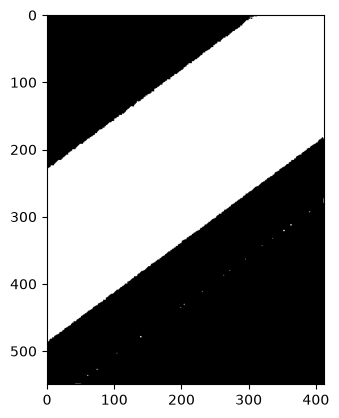

In [22]:
plt.imshow(thresh1, cmap='gray')

### Binary Inverse

$$
dst(x,y)=
\begin{cases}
0 & \text{if } src(x,y) > 127 \\
maxval & \text{if } src(x,y) \leq 127
\end{cases}
$$

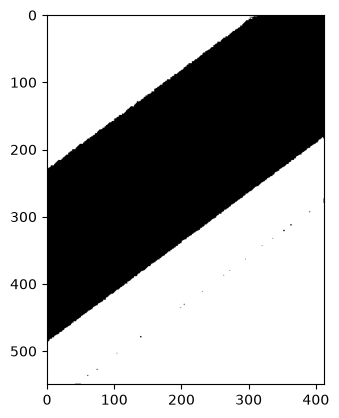

In [23]:
ret, thresh2 = cv2.threshold(src=img,                     # input image: should be gray-scaled
                             thresh=127,                  # compares every pixel against 127
                             maxval=255,                  # all pixels ≤ 127 will be white color
                             type=cv2.THRESH_BINARY_INV)  # thresholding method to use 
# Therefore, the grayscale image becomes a black-and-white binary image.
# 'ret' includes threshold value and thresh1 includes resulting thresholded image

plt.imshow(thresh2, cmap='gray')

###  Threshold Truncation

$$
dst(x,y)=
\begin{cases}
thresh & \text{if } src(x,y) > 127 \\
maxval & \text{if } src(x,y) \leq 127
\end{cases}
$$

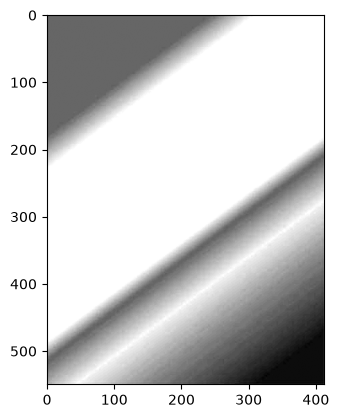

In [25]:
ret, thresh3 = cv2.threshold(src=img,                     # input image: should be gray-scaled
                             thresh=127,                  # compares every pixel against 127
                             maxval=255,                  # all pixels > 127 will be threshold color
                             type=cv2.THRESH_TRUNC)       # thresholding method to use 
# Therefore, the grayscale image becomes a threshold-and-white binary image.
# 'ret' includes threshold value and thresh1 includes resulting thresholded image

plt.imshow(thresh3, cmap='gray')

### Threshold to Zero

$$
dst(x,y)=
\begin{cases}
src(x,y) & \text{if } src(x,y) > 127 \\
0 & \text{if } src(x,y) \leq 127
\end{cases}
$$

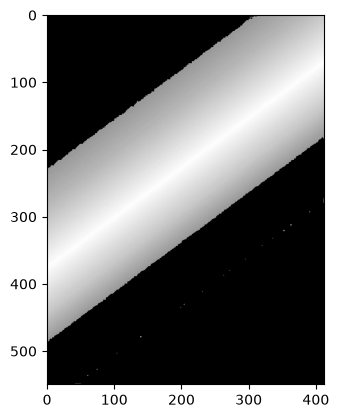

In [26]:
ret, thresh4 = cv2.threshold(src=img,                     # input image: should be gray-scaled
                             thresh=127,                  # compares every pixel against 127
                             maxval=255,                  # all pixels > 127 will be threshold color
                             type=cv2.THRESH_TOZERO)      # thresholding method to use 
# Therefore, the grayscale image becomes a black-and-white binary image.
# 'ret' includes threshold value and thresh1 includes resulting thresholded image

plt.imshow(thresh4, cmap='gray')

### Threshold to Zero (Inverse)

$$
dst(x,y)=
\begin{cases}
0 & \text{if } src(x,y) > 127 \\
src(x,y) & \text{if } src(x,y) \leq 127
\end{cases}
$$

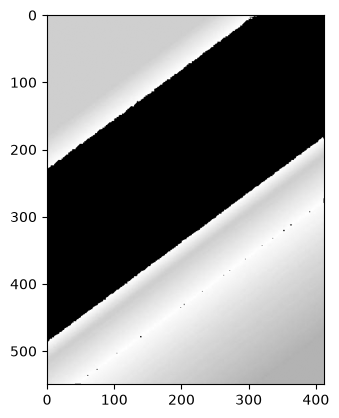

In [29]:
ret, thresh4 = cv2.threshold(src=img,                     # input image: should be gray-scaled
                             thresh=127,                  # compares every pixel against 127
                             maxval=255,                  # all pixels > 127 will be black color
                             type=cv2.THRESH_TOZERO_INV)  # thresholding method to use 
# Therefore, the grayscale image becomes a black-and-white binary image.
# 'ret' includes threshold value and thresh1 includes resulting thresholded image

plt.imshow(thresh4, cmap='gray')

# Real World Applications

## Adaptive Thresholding



### Sudoku Image

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
img = cv2.imread('data/crossword.jpg', 0)

In [3]:
def show_pic(img):
    fig = plt.figure(figsize=(15,15))
    ax = fig.add_subplot(111)
    ax.imshow(img, cmap='gray')

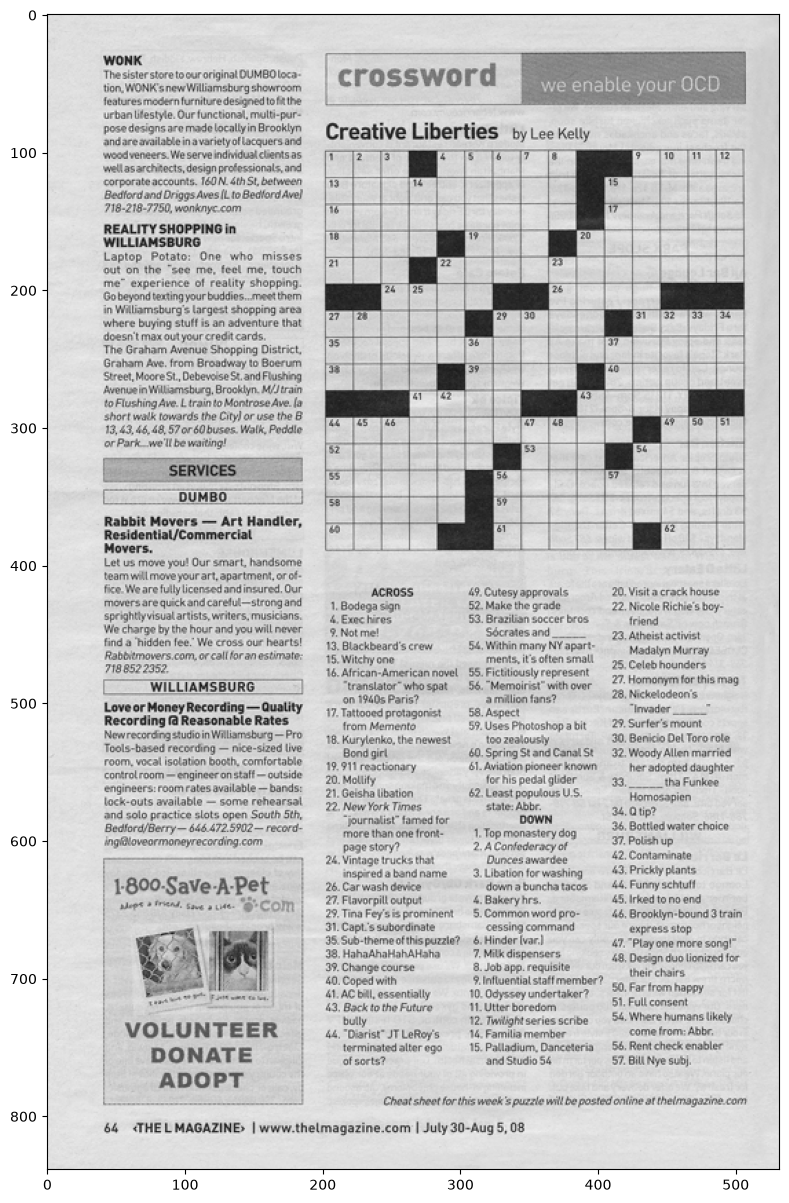

In [4]:
show_pic(img)

## Simple Binary

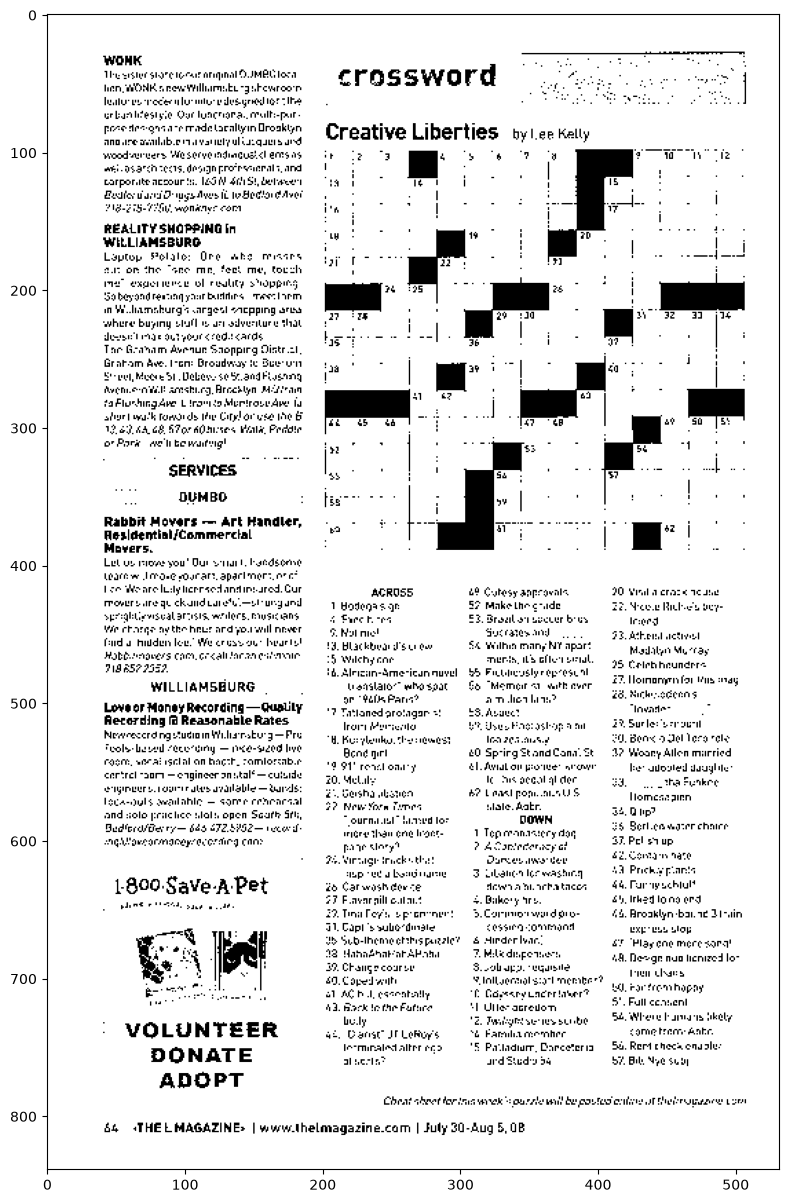

In [11]:
ret, th1 = cv2.threshold(src = img,
                         thresh = 127,
                         maxval = 255,
                         type = cv2.THRESH_BINARY)
show_pic(th1)

### Adaptive Threshold

https://stackoverflow.com/questions/28763419/adaptive-threshold-parameters-confusion

    @param src Source 8-bit single-channel image.
    .   @param dst Destination image of the same size and the same type as src.
    .   @param maxValue Non-zero value assigned to the pixels for which the condition is satisfied
    .   @param adaptiveMethod Adaptive thresholding algorithm to use, see #AdaptiveThresholdTypes.
    .   The #BORDER_REPLICATE | #BORDER_ISOLATED is used to process boundaries.
    .   @param thresholdType Thresholding type that must be either #THRESH_BINARY or #THRESH_BINARY_INV,
    .   see #ThresholdTypes.
    .   @param blockSize Size of a pixel neighborhood that is used to calculate a threshold value for the
    .   pixel: 3, 5, 7, and so on.
    .   @param C Constant subtracted from the mean or weighted mean (see the details below). Normally, it
    .   is positive but may be zero or negative as well.

In [5]:
th2 = cv2.adaptiveThreshold(src = img,  # input grayscale image
                            maxValue = 255,  # maximum output pixel value
                            adaptiveMethod = cv2.ADAPTIVE_THRESH_MEAN_C,  # local threshold using the neighborhood mean
                            thresholdType = cv2.THRESH_BINARY,  # pixels above the threshold become white; others become black
                            blockSize = 11,  # size of the local neighborhood: (11 x 11) pixels
                            C = 8)  # constant (C), subtracted from the calculated local mean


**How does it operate?**

- Imagine OpenCV is processing one pixel whose intensity is `140`.  
- First, it examines the surrounding (11 $\times$ 11) neighborhood, containing `121` pixels.
- Suppose their average intensity is `150`.  

**Step 1 — Calculate the local threshold**
$$T(x,y)=\operatorname{Mean}(N_{x,y})-C$$
$$T(x,y)=150-8=142$$

---

**Step 2 — Compare the current pixel with the threshold**  
- The current pixel value is `140`.
- Since ($140 \leq 142$), its output becomes `0` (black).  
- If the current pixel were `160`, its output would become `255` (white).

| Current pixel	| Local threshold | Output |
|---------------|-----------------|--------|
| 140 | 142 | 0 (black) |
| 142 |	142	| 0 (black) |
| 143 | 142	| 255 (white) |
| 160 |	142 | 255 (white) |

This calculation is repeated for every pixel, using its own local neighborhood.

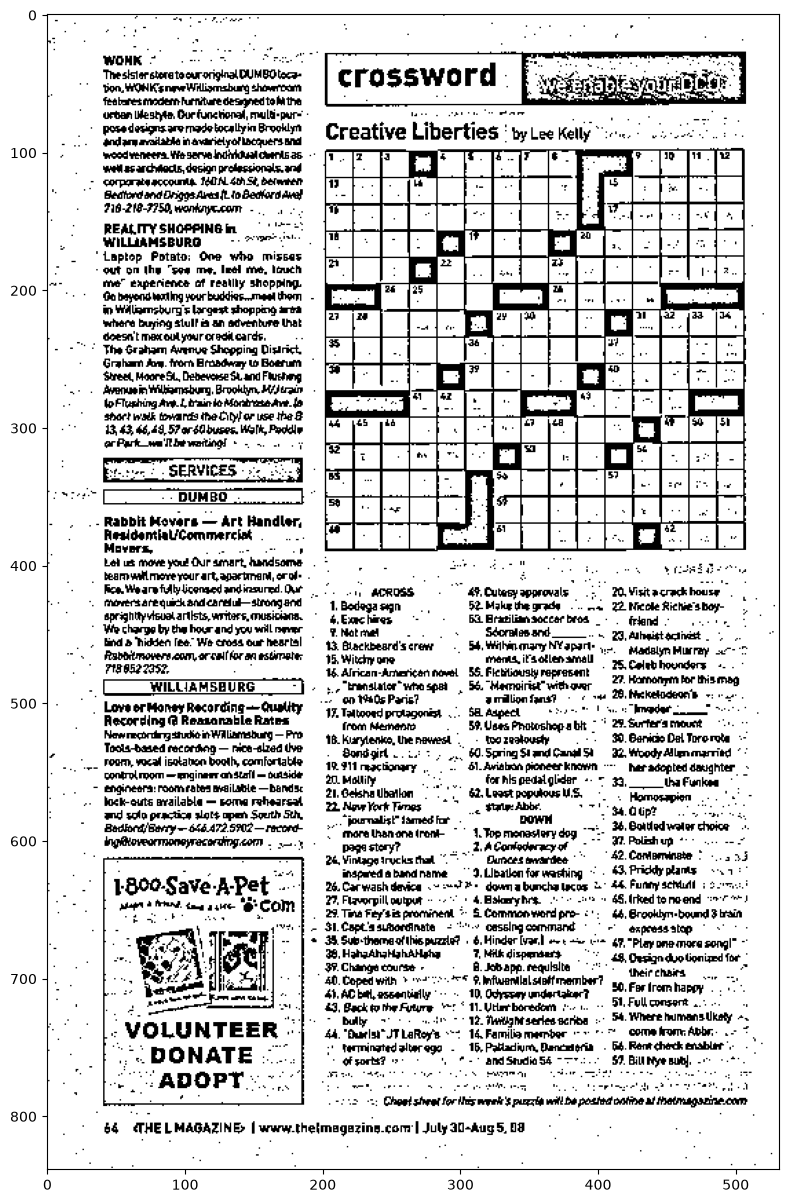

In [6]:
show_pic(th2)

In [8]:
th3 = cv2.adaptiveThreshold(src = img,  # input grayscale image
                            maxValue = 255,  # maximum output pixel value
                            adaptiveMethod = cv2.ADAPTIVE_THRESH_GAUSSIAN_C,  # local threshold using the neighborhood mean
                            thresholdType = cv2.THRESH_BINARY,  # pixels above the threshold become white; others become black
                            blockSize = 15,  # size of the local neighborhood: (11 x 11) pixels
                            C = 8)  # constant (C), subtracted from the calculated local mean


![image](data/adaptive_mean_vs_gaussian.png)


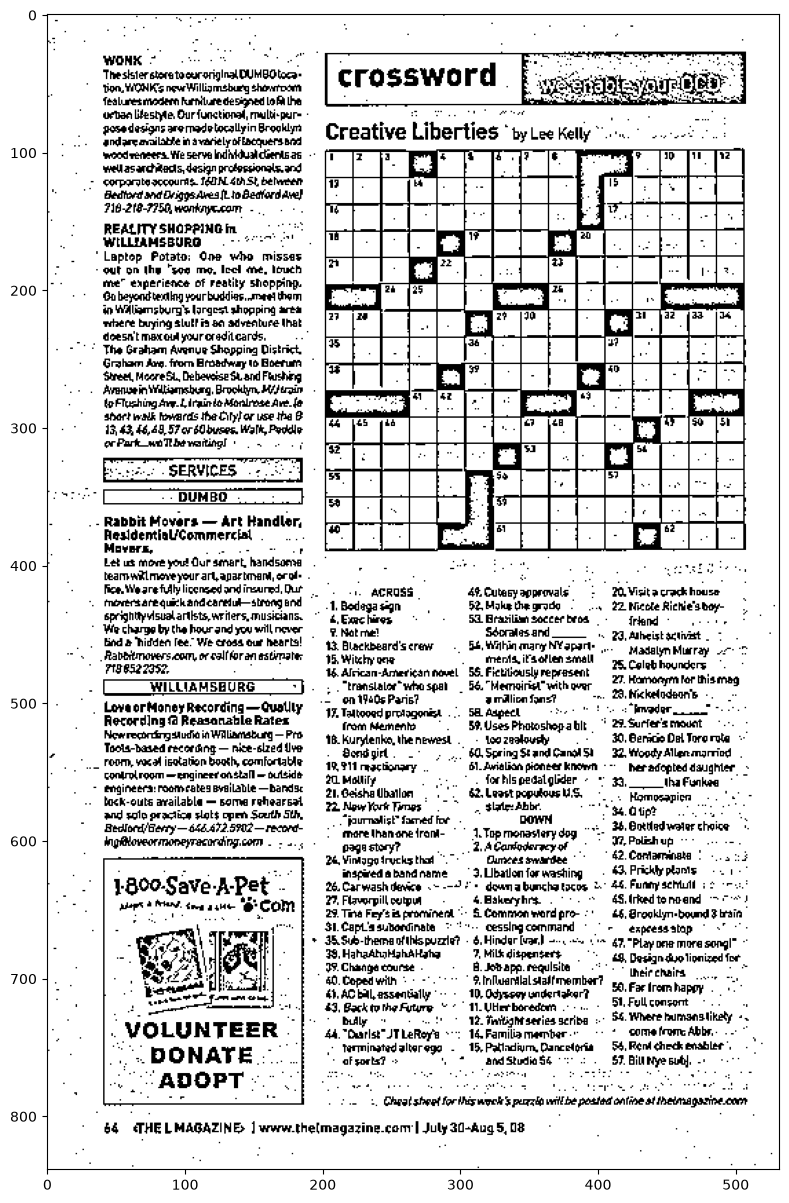

In [9]:
show_pic(th3)

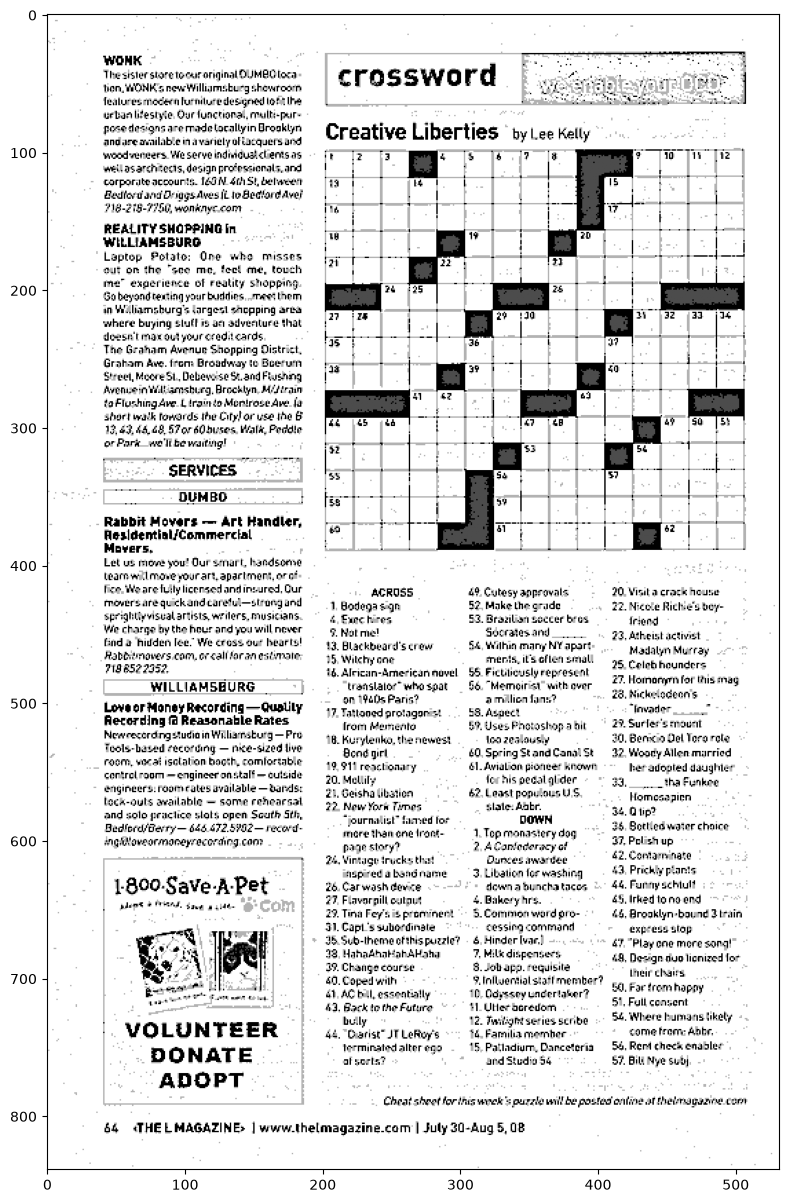

In [12]:
blended = cv2.addWeighted(src1=th1, alpha=0.7, src2=th3, beta=0.3, gamma=0)
show_pic(blended)

## Great Work!